**Here we have a real estate data, build a predictive model to predict price of a property if other factors are known**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('https://github.com/bipulshahi/Dataset/raw/refs/heads/main/Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.shape

(13320, 9)

In [ ]:
df.dtypes

,0
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64


In [ ]:
df.nunique()

,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


In [ ]:
df.isna().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
df['area_type'].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


In [ ]:
df1 = df.copy()

In [ ]:
df1['area_type'] = df1['area_type'].str.lower()      #convert all text into lower case
df1['area_type'] = df1['area_type'].str.strip()      #remove any extra leading or lagging spaces

In [ ]:
df1['area_type'].unique()

array(['super built-up  area', 'plot  area', 'built-up  area',
       'carpet  area'], dtype=object)

In [ ]:
df1['area_type'] = df1['area_type'].apply(lambda x : "super built-up area" if x == "super built-up  area" else 'Others')

In [ ]:
df1['area_type'].value_counts()

,count
area_type,
super built-up area,8790
Others,4530


In [ ]:
df1['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr', '16-Jan', '14-Jul'], dtype=object)

In [ ]:
df1['availability'].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


In [ ]:
df1['availability'] = df1['availability'].apply(lambda x : "UC" if x != "Ready To Move" else x)

In [ ]:
df1['availability'].value_counts()

,count
availability,
Ready To Move,10581
UC,2739


In [ ]:
df1['location'] = df1['location'].str.lower()
df1['location'] = df1['location'].str.strip()

In [ ]:
location_count = df1['location'].value_counts()
location_count

,count
location,
whitefield,541
sarjapur road,399
electronic city,304
kanakpura road,273
thanisandra,237
...,...
pattegarhpalya,1
sarvobhogam nagar,1
prasanna layout herohalli,1


**filter the data for locations where atleast we have 50 samples**

In [ ]:
location_count[location_count < 30]

,count
location,
btm 2nd stage,29
kammasandra,29
kudlu,29
dodda nekkundi,29
padmanabhanagar,28
...,...
pattegarhpalya,1
sarvobhogam nagar,1
prasanna layout herohalli,1


In [ ]:
less_count_location = location_count[location_count < 30].index.to_list()
less_count_location

['btm 2nd stage',
 'kammasandra',
 'kudlu',
 'dodda nekkundi',
 'padmanabhanagar',
 'somasundara palya',
 'horamavu banaswadi',
 'ambalipura',
 'anandapura',
 'singasandra',
 'kodichikkanahalli',
 'banashankari stage iii',
 'gubbalala',
 'choodasandra',
 'bommasandra industrial area',
 'margondanahalli',
 'kothannur',
 'magadi road',
 'iblur village',
 '1st phase jp nagar',
 'seegehalli',
 'babusapalaya',
 'kogilu',
 'battarahalli',
 'ardendale',
 'munnekollal',
 'kambipura',
 'abbigere',
 '2nd stage nagarbhavi',
 'amruthahalli',
 '6th phase jp nagar',
 'lingadheeranahalli',
 'epip zone',
 'kathriguppe',
 'kaval byrasandra',
 'gunjur',
 'thubarahalli',
 'domlur',
 'sonnenahalli',
 'hoskote',
 'rayasandra',
 'basaveshwara nagar',
 'binny pete',
 'ulsoor',
 'sanjay nagar',
 'yelachenahalli',
 'poorna pragna layout',
 'hbr layout',
 'pai layout',
 'hrbr layout',
 'kalyan nagar',
 'kaggalipura',
 'ombr layout',
 'kannamangala',
 'billekahalli',
 'bannerghatta',
 'garudachar palya',
 'dasar

In [ ]:
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Others,Ready To Move,chikka tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Others,Ready To Move,uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,super built-up area,Ready To Move,lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,super built-up area,Ready To Move,kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
def filter_location(name_of_location):
  return name_of_location not in less_count_location

In [ ]:
filter_location('electronic city phase ii')

True

In [ ]:
#Data samples where at least we have 30 or more samples
df2 = df1[df1['location'].apply(filter_location)]

In [ ]:
df2.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2 BHK,Coomee,1056,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4 BHK,Jaades,2732,4.0,NaN,204.00


In [ ]:
df2['location'].value_counts()

,count
location,
whitefield,541
sarjapur road,399
electronic city,304
kanakpura road,273
thanisandra,237
...,...
ambedkar nagar,31
chikkalasandra,30
doddathoguru,30


In [ ]:
df2.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2 BHK,Coomee,1056,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4 BHK,Jaades,2732,4.0,NaN,204.00


In [ ]:
df2['size'].unique()

array(['2 BHK', '3 BHK', '4 BHK', '4 Bedroom', '3 Bedroom', '1 BHK',
       '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom', '6 Bedroom',
       '5 BHK', '5 Bedroom', '7 BHK', nan, '7 Bedroom', '9 Bedroom',
       '6 BHK', '10 Bedroom', '9 BHK', '12 Bedroom', '8 BHK'],
      dtype=object)

In [ ]:
text = '2 BHK'
int(text.split(' ')[0])

2

In [ ]:
def fix_size(size):
  try:
    return int(size.split(' ')[0])
  except:
    return size

In [ ]:
df2['size'] = df2['size'].apply(fix_size)

/tmp/ipython-input-31-3242310510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['size'] = df2['size'].apply(fix_size)


In [ ]:
df2.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2.0,Coomee,1056,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3.0,NaN,1440,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2.0,NaN,1200,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2.0,DuenaTa,1170,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4.0,Jaades,2732,4.0,NaN,204.00


In [ ]:
df2['society'].isna().sum()

np.int64(2367)

In [ ]:
df2['society'].isna().sum()/len(df2)

np.float64(0.29807329051756704)

In [ ]:
df2['society'].unique()

array(['Coomee ', nan, 'DuenaTa', ..., 'Saentpa', 'AeisePV', 'SJovest'],
      dtype=object)

In [ ]:
df2['society'].value_counts()

,count
society,
GrrvaGr,80
PrarePa,74
Sryalan,59
Prtates,59
GMown E,56
...,...
Upldsin,1
ARnts A,1
JHk 1en,1


In [ ]:
df3 = df2.drop(columns = 'society')

In [ ]:
df3.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2.0,1056,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3.0,1440,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2.0,1200,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2.0,1170,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4.0,2732,4.0,NaN,204.00


In [ ]:
df3.dtypes

,0
area_type,object
availability,object
location,object
size,float64
total_sqft,object
bath,float64
balcony,float64
price,float64


In [ ]:
df3.nunique()

,0
area_type,2
availability,2
location,100
size,11
total_sqft,1678
bath,13
balcony,4
price,1582


In [ ]:
df3.isna().sum()

,0
area_type,0
availability,0
location,1
size,12
total_sqft,0
bath,66
balcony,328
price,0


In [ ]:
df4 = df3.dropna(subset=['location'])
df4.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2.0,1056,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3.0,1440,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2.0,1200,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2.0,1170,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4.0,2732,4.0,NaN,204.00


In [ ]:
df4['size'].unique()

array([ 2.,  3.,  4.,  1.,  8.,  6.,  5.,  7., nan,  9., 10., 12.])

In [ ]:
df4['size'].value_counts()

,count
size,
2.0,3471
3.0,3023
4.0,724
1.0,417
5.0,139
6.0,61
8.0,34
7.0,34
9.0,22


In [ ]:
df5 = df4[~(df4['size'] > 6)]
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2.0,1056,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3.0,1440,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2.0,1200,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2.0,1170,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4.0,2732,4.0,NaN,204.00


In [ ]:
df5['size'].isna().sum()

np.int64(12)

In [ ]:
df5['size'].value_counts()

,count
size,
2.0,3471
3.0,3023
4.0,724
1.0,417
5.0,139
6.0,61


In [ ]:
df5.dtypes

,0
area_type,object
availability,object
location,object
size,float64
total_sqft,object
bath,float64
balcony,float64
price,float64


In [ ]:
text = '2100 - 2850'
(int(text.split('-')[0]) + int(text.split('-')[1]))/2

2475.0

In [ ]:
def fix_total_sqft(area):
  try:
    return float(area)
  except:
    try:
      return (int(area.split('-')[0]) + int(area.split('-')[1]))/2
    except:
      return np.nan

In [ ]:
df5['total_sqft'] = df5['total_sqft'].apply(fix_total_sqft)

/tmp/ipython-input-51-785805872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['total_sqft'] = df5['total_sqft'].apply(fix_total_sqft)


In [ ]:
df5['total_sqft'].isna().sum()

np.int64(23)

In [ ]:
df5.isna().sum()

,0
area_type,0
availability,0
location,0
size,12
total_sqft,23
bath,66
balcony,301
price,0


In [ ]:
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2.0,1056.0,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3.0,1440.0,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2.0,1200.0,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2.0,1170.0,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4.0,2732.0,4.0,NaN,204.00


In [ ]:
df5['total_sqft'].mean()

np.float64(1513.420327198364)

In [ ]:
df5[(df5['size'].isna()) & (df5['total_sqft'].isna())]

,area_type,availability,location,size,total_sqft,bath,balcony,price


In [ ]:
size_sqft = df5.groupby('size')['total_sqft'].mean()
size_sqft

,total_sqft
size,
1.0,730.333738
2.0,1142.219666
3.0,1664.635904
4.0,2831.338033
5.0,2758.800360
6.0,1964.524098


In [ ]:
def fix_missing_sqft(size):
  try:
    return size_sqft[size]
  except:
    pass

In [ ]:
fix_missing_sqft(2)

np.float64(1142.219665513264)

In [ ]:
df5['size'].apply(fix_missing_sqft)

,size
0,1142.219666
2,1664.635904
4,1142.219666
5,1142.219666
6,2831.338033
...,...
13313,1664.635904
13314,1664.635904
13315,2758.800360
13317,1142.219666


In [ ]:
df5['total_sqft'] = df5['total_sqft'].fillna(df5['size'].apply(fix_missing_sqft))

/tmp/ipython-input-61-936903648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['total_sqft'] = df5['total_sqft'].fillna(df5['size'].apply(fix_missing_sqft))


In [ ]:
df5['total_sqft'].isna().sum()

np.int64(0)

In [ ]:
df5.isna().sum()

,0
area_type,0
availability,0
location,0
size,12
total_sqft,0
bath,66
balcony,301
price,0


In [ ]:
size_sqft_2 = df5.groupby('size')['total_sqft'].agg(['mean','std'])
size_sqft_2

,mean,std
size,,
1.0,730.333738,1271.780096
2.0,1142.219666,179.551298
3.0,1664.635904,820.927953
4.0,2831.338033,1275.590617
5.0,2758.800360,1984.484410
6.0,1964.524098,1168.501370


In [ ]:
def fix_size(sqft):
  if sqft < 1000:
    return 1
  elif sqft < 1500:
    return 2
  elif sqft < 2000:
    return 3
  elif sqft < 2500:
    return 4
  elif sqft < 3000:
    return 5
  else:
    return 6

In [ ]:
df5['total_sqft'].apply(fix_size)

,total_sqft
0,2
2,2
4,2
5,2
6,5
...,...
13313,2
13314,3
13315,6
13317,2


In [ ]:
df5['size'] = df5['size'].fillna(df5['total_sqft'].apply(fix_size))

/tmp/ipython-input-67-2107841801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['size'] = df5['size'].fillna(df5['total_sqft'].apply(fix_size))


In [ ]:
df5.isna().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,66
balcony,301
price,0


In [ ]:
df5['bath'].unique()

array([ 2.,  4.,  3.,  5.,  1., nan,  7.,  6.,  8.])

In [ ]:
df5['bath'].value_counts()

,count
bath,
2.0,4324
3.0,1963
4.0,643
1.0,486
5.0,249
6.0,103
7.0,12
8.0,1


In [ ]:
df5['bath'] = df5['bath'].fillna(df5['size'] + 1)

/tmp/ipython-input-71-3774288958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['bath'] = df5['bath'].fillna(df5['size'] + 1)


In [ ]:
df5.isna().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,301
price,0


In [ ]:
df5['balcony'].unique()

array([ 1.,  3., nan,  2.,  0.])

In [ ]:
pd.crosstab(df5['size'] , df['balcony'])

balcony,0.0,1.0,2.0,3.0
size,,,,
1.0,99,292,17,1
2.0,183,1836,1248,181
3.0,99,781,1490,523
4.0,98,131,220,179
5.0,19,31,34,29
6.0,10,11,18,16


In [ ]:
df5['size'].apply(lambda x : 1 if x <= 2 else 2)

,size
0,1
2,2
4,1
5,1
6,2
...,...
13313,2
13314,2
13315,2
13317,1


In [ ]:
df5['balcony'] = df5['balcony'].fillna(df5['size'].apply(lambda x : 1 if x <= 2 else 2))

/tmp/ipython-input-76-3104076037.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['balcony'] = df5['balcony'].fillna(df5['size'].apply(lambda x : 1 if x <= 2 else 2))


In [ ]:
df5.isna().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [ ]:
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,super built-up area,UC,electronic city phase ii,2.0,1056.0,2.0,1.0,39.07
2,Others,Ready To Move,uttarahalli,3.0,1440.0,2.0,3.0,62.00
4,super built-up area,Ready To Move,kothanur,2.0,1200.0,2.0,1.0,51.00
5,super built-up area,Ready To Move,whitefield,2.0,1170.0,2.0,1.0,38.00
6,super built-up area,UC,old airport road,4.0,2732.0,4.0,2.0,204.00


In [ ]:
df5.describe()

,size,total_sqft,bath,balcony,price
count,7847.000000,7847.000000,7847.000000,7847.000000,7847.000000
mean,2.603160,1514.109267,2.526953,1.591946,98.577685
std,0.856387,939.871016,0.975748,0.779665,104.667404
min,1.000000,1.000000,1.000000,0.000000,8.000000
25%,2.000000,1108.500000,2.000000,1.000000,48.000000
50%,3.000000,1285.000000,2.000000,2.000000,69.000000
75%,3.000000,1661.000000,3.000000,2.000000,109.000000
max,6.000000,35000.000000,8.000000,3.000000,1800.000000


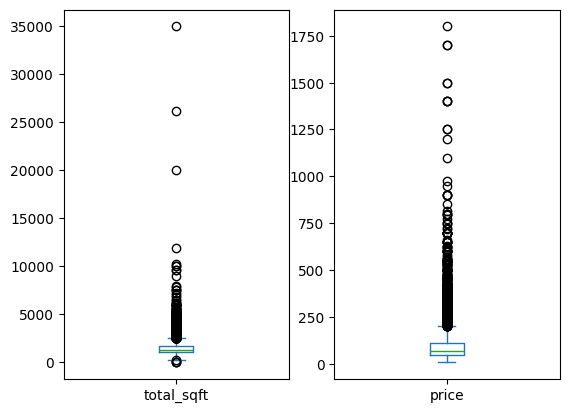

In [ ]:
plt.subplot(1,2,1)
df5['total_sqft'].plot.box()

plt.subplot(1,2,2)
df5['price'].plot.box()

plt.show()

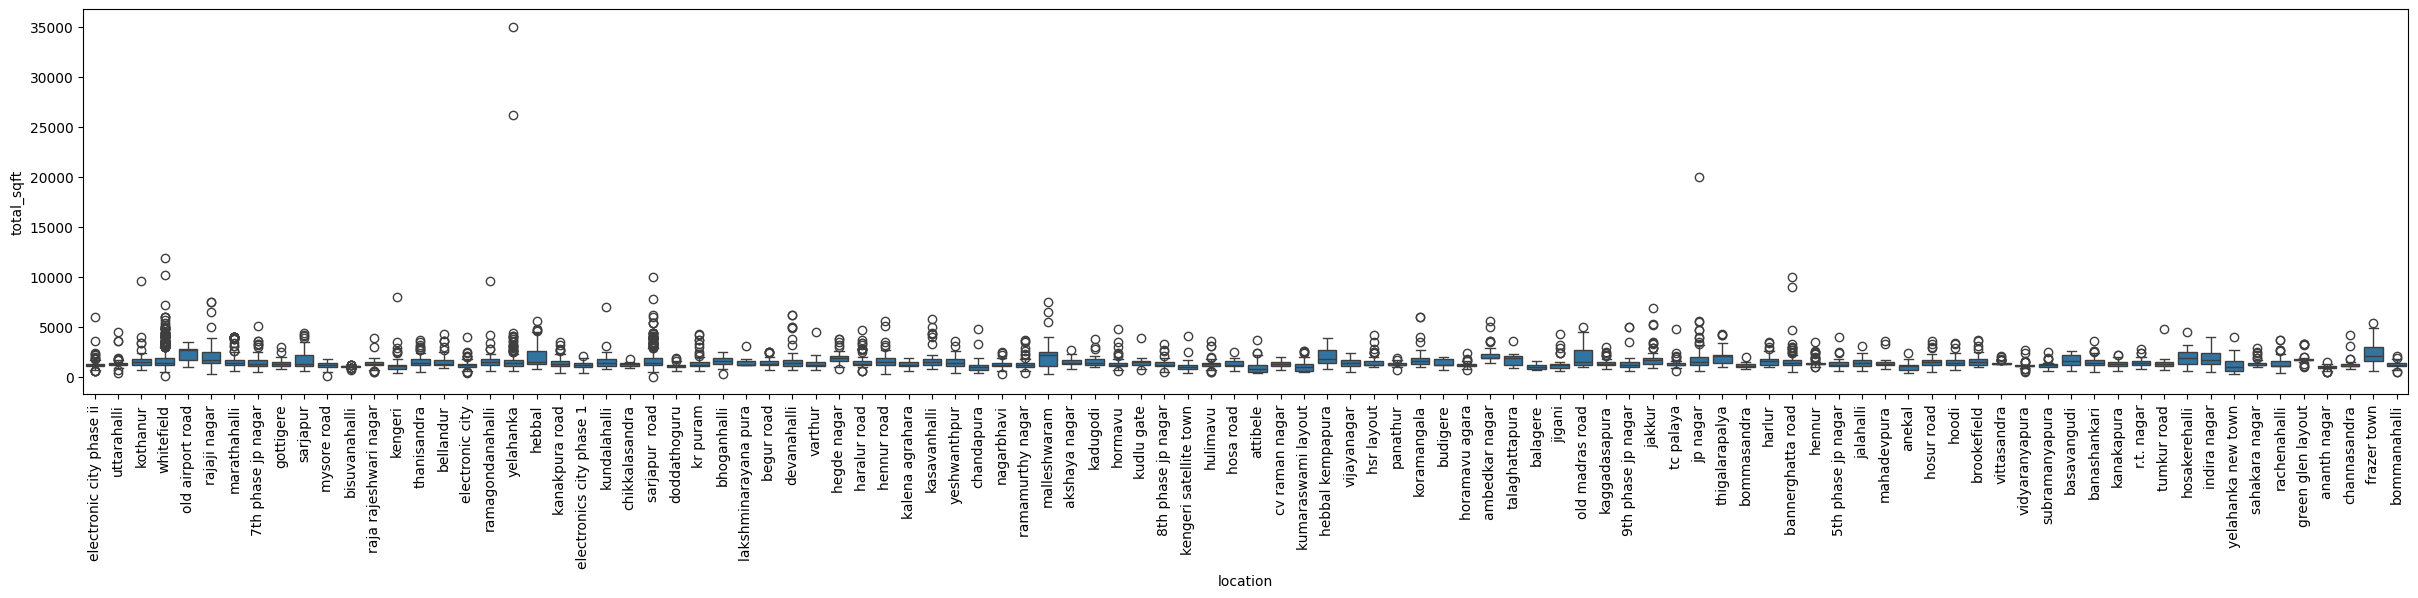

In [ ]:
import seaborn as sns

plt.figure(figsize = (30,5))
sns.boxplot(x = df5['location']  , y = df5['total_sqft'])

plt.xticks(rotation = 90)
plt.show()

In [ ]:
df5['PPS'] = (df5['price']*100000)/df5['total_sqft']

/tmp/ipython-input-82-2844756256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['PPS'] = (df5['price']*100000)/df5['total_sqft']


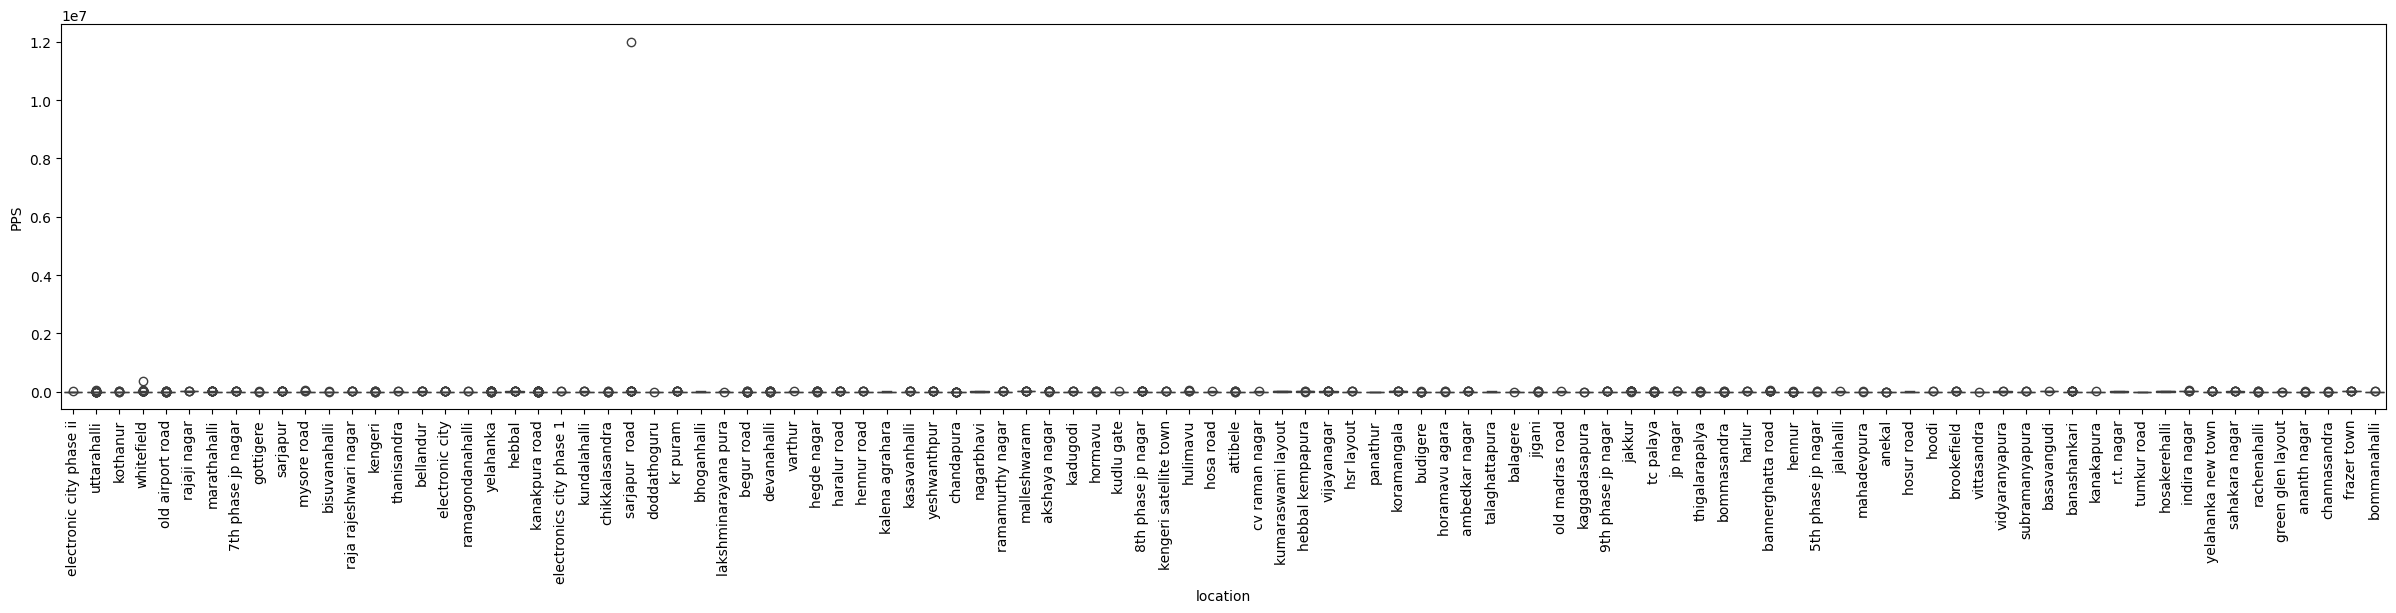

In [ ]:
import seaborn as sns

plt.figure(figsize = (30,5))
sns.boxplot(x = df5['location']  , y = df5['PPS'])

plt.xticks(rotation = 90)
plt.show()

In [ ]:
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,PPS
0,super built-up area,UC,electronic city phase ii,2.0,1056.0,2.0,1.0,39.07,3699.810606
2,Others,Ready To Move,uttarahalli,3.0,1440.0,2.0,3.0,62.00,4305.555556
4,super built-up area,Ready To Move,kothanur,2.0,1200.0,2.0,1.0,51.00,4250.000000
5,super built-up area,Ready To Move,whitefield,2.0,1170.0,2.0,1.0,38.00,3247.863248
6,super built-up area,UC,old airport road,4.0,2732.0,4.0,2.0,204.00,7467.057101


In [ ]:
df6 = pd.DataFrame()

for location,group in df5.groupby('location'):
  #print(location)
  #print(group['total_sqft'])
  q1 = group['total_sqft'].quantile(0.25)         #per group quantile 1
  q3 = group['total_sqft'].quantile(0.75)         #per group quantile 3
  iqr = q3 - q1                                    #per group iqr
  upper_limit = q3 + 1.5 * iqr                    #per group upper limit
  lower_limit = q1 - 1.5 * iqr                    #per group lower limit
  group['total_sqft'] = group['total_sqft'].clip(upper = upper_limit, lower = lower_limit)         #replacing per group upper and lower limits
  df6 = pd.concat((df6 , group))                     #Updating into df6

In [ ]:
df6.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,PPS
367,super built-up area,Ready To Move,5th phase jp nagar,2.0,1075.0,2.0,2.0,60.0,5581.395349
493,Others,Ready To Move,5th phase jp nagar,2.0,1150.0,3.0,3.0,52.5,4565.217391
760,super built-up area,UC,5th phase jp nagar,2.0,1070.0,2.0,2.0,39.0,3644.859813
1012,Others,Ready To Move,5th phase jp nagar,2.0,1256.0,2.0,1.0,62.8,5000.000000
1493,super built-up area,Ready To Move,5th phase jp nagar,2.0,1207.0,2.0,2.0,63.0,5219.552610


In [ ]:
df6.describe()

,size,total_sqft,bath,balcony,price,PPS
count,7847.000000,7847.000000,7847.000000,7847.000000,7847.000000,7.847000e+03
mean,2.603160,1439.859091,2.526953,1.591946,98.577685,7.610647e+03
std,0.856387,567.586494,0.975748,0.779665,104.667404,1.354973e+05
min,1.000000,117.500000,1.000000,0.000000,8.000000,3.714286e+02
25%,2.000000,1109.000000,2.000000,1.000000,48.000000,4.200000e+03
50%,3.000000,1286.000000,2.000000,2.000000,69.000000,5.300078e+03
75%,3.000000,1655.500000,3.000000,2.000000,109.000000,6.764516e+03
max,6.000000,4965.625000,8.000000,3.000000,1800.000000,1.200000e+07


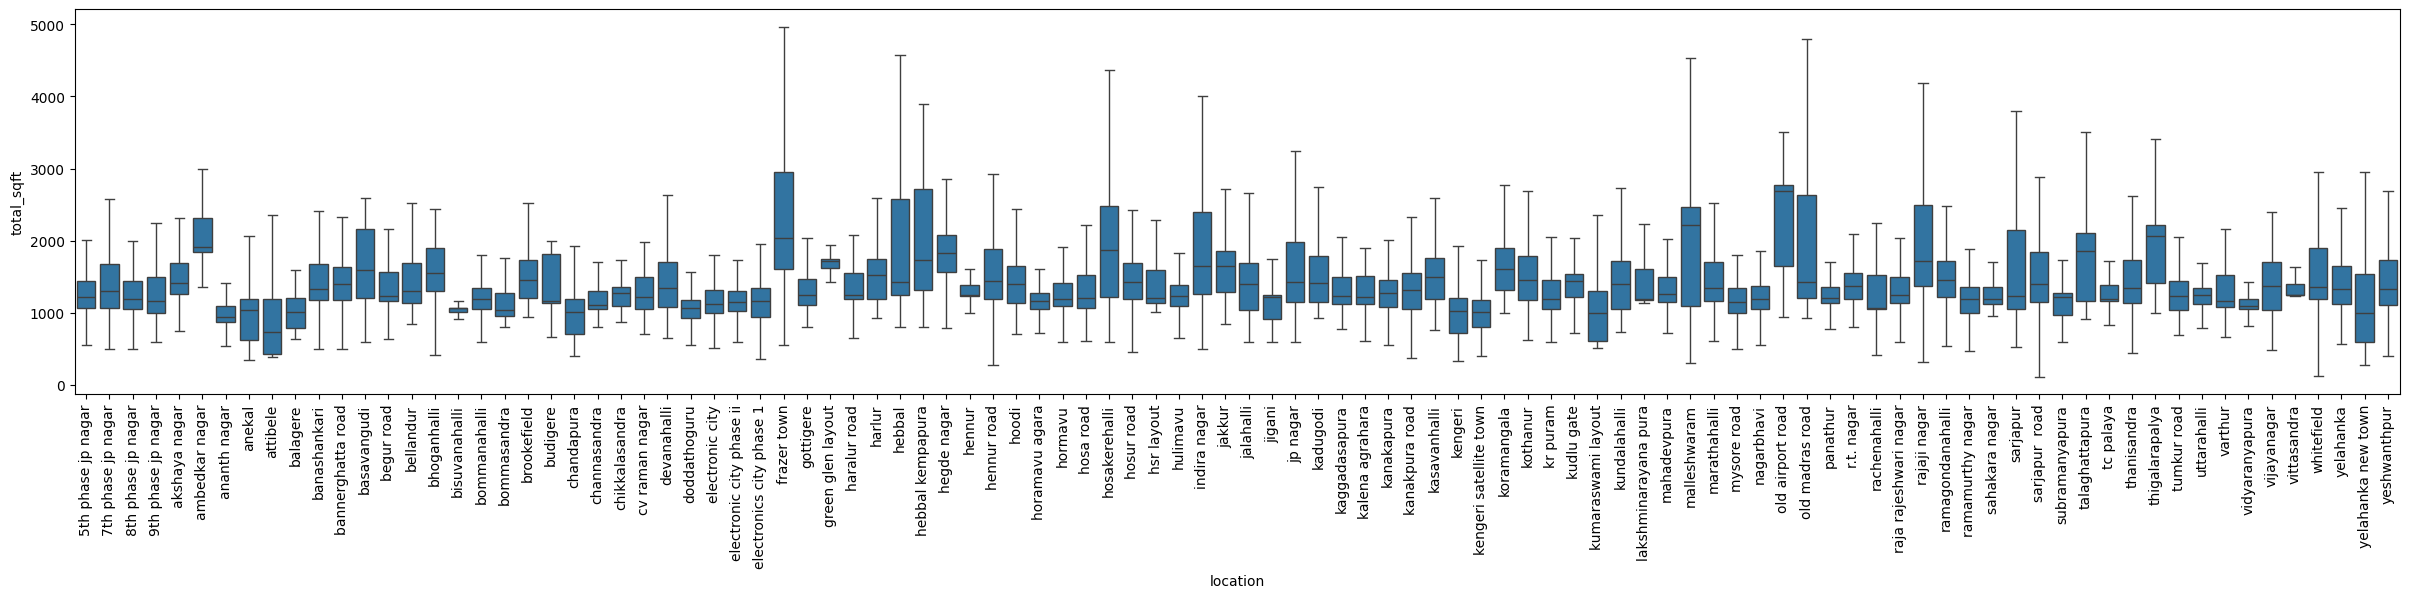

In [ ]:
import seaborn as sns

plt.figure(figsize = (30,5))
sns.boxplot(x = df6['location']  , y = df6['total_sqft'])

plt.xticks(rotation = 90)
plt.show()

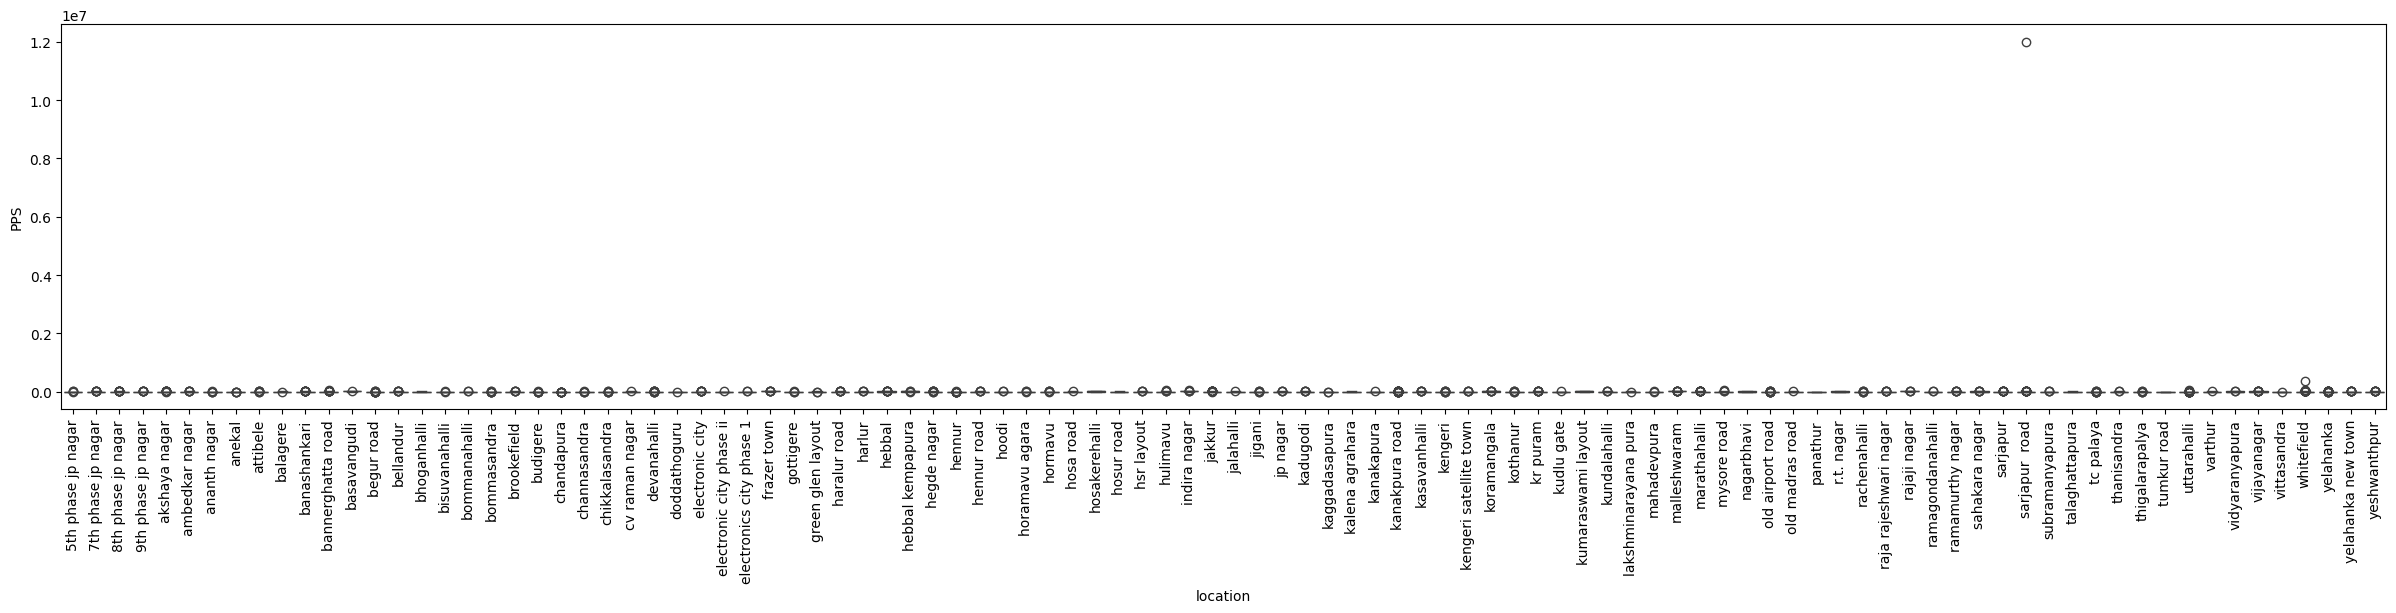

In [ ]:
import seaborn as sns

plt.figure(figsize = (30,5))
sns.boxplot(x = df6['location']  , y = df6['PPS'])

plt.xticks(rotation = 90)
plt.show()

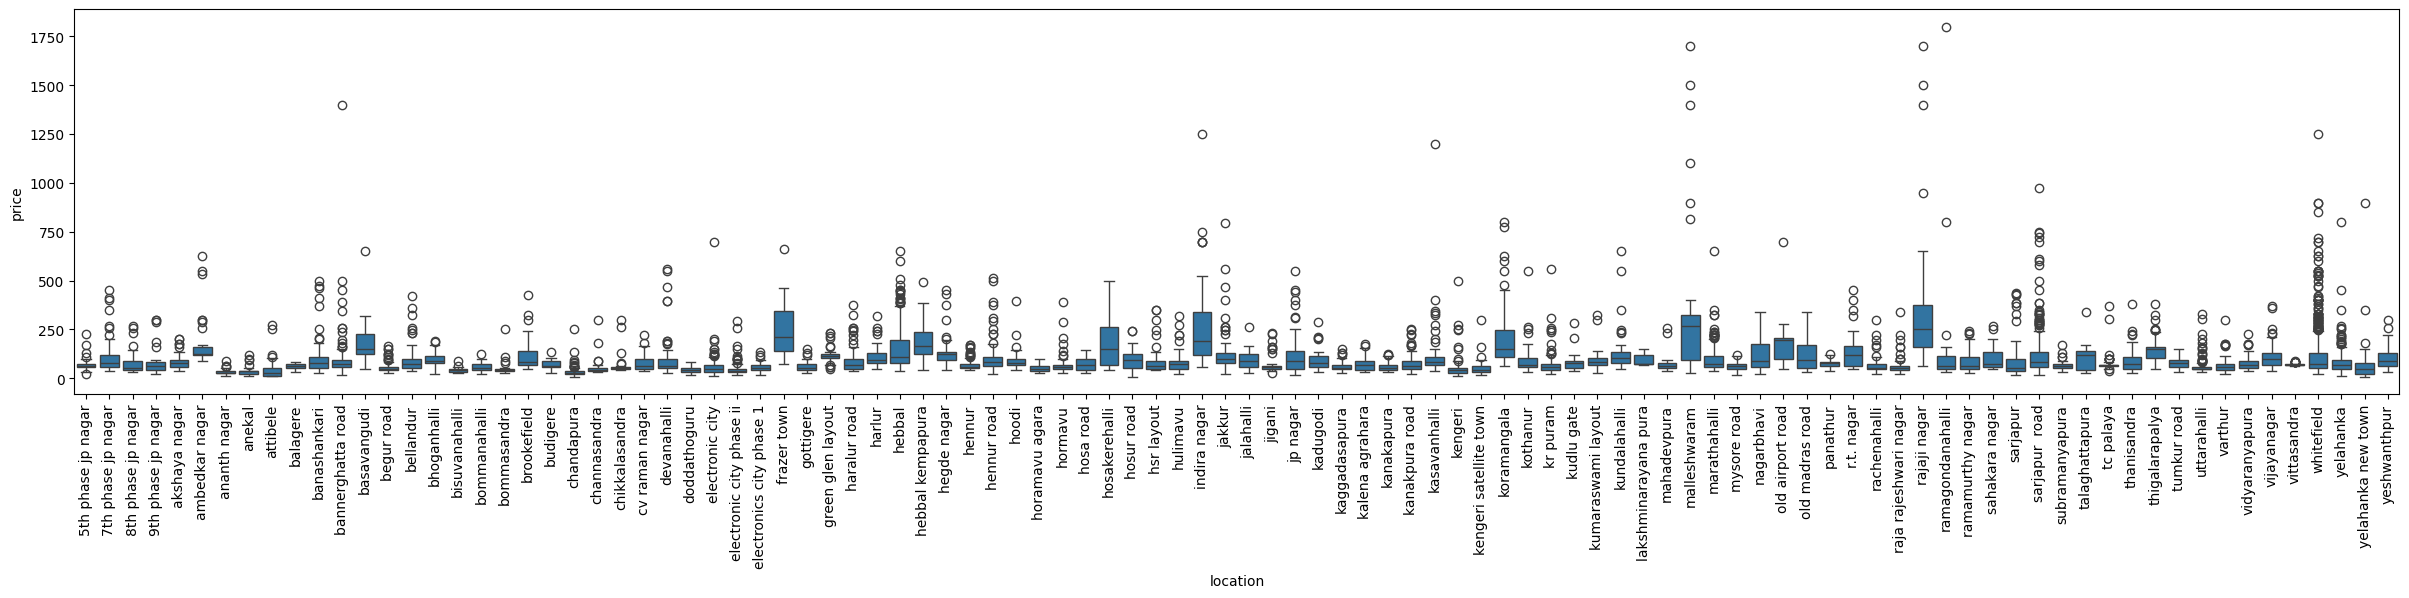

In [ ]:
import seaborn as sns

plt.figure(figsize = (30,5))
sns.boxplot(x = df6['location']  , y = df6['price'])

plt.xticks(rotation = 90)
plt.show()

In [ ]:
df7 = pd.DataFrame()

for location,group in df6.groupby('location'):
  #print(location)
  #print(group['total_sqft'])
  q1 = group['PPS'].quantile(0.25)         #per group quantile 1
  q3 = group['PPS'].quantile(0.75)         #per group quantile 3
  iqr = q3 - q1                                    #per group iqr
  upper_limit = q3 + 1.5 * iqr                    #per group upper limit
  lower_limit = q1 - 1.5 * iqr                    #per group lower limit
  group['PPS'] = group['PPS'].clip(upper = upper_limit, lower = lower_limit)         #replacing per group upper and lower limits
  df7 = pd.concat((df7 , group))                     #Updating into df6

In [ ]:
df7['price'] = (df7['total_sqft'] * df7['PPS'])/100000

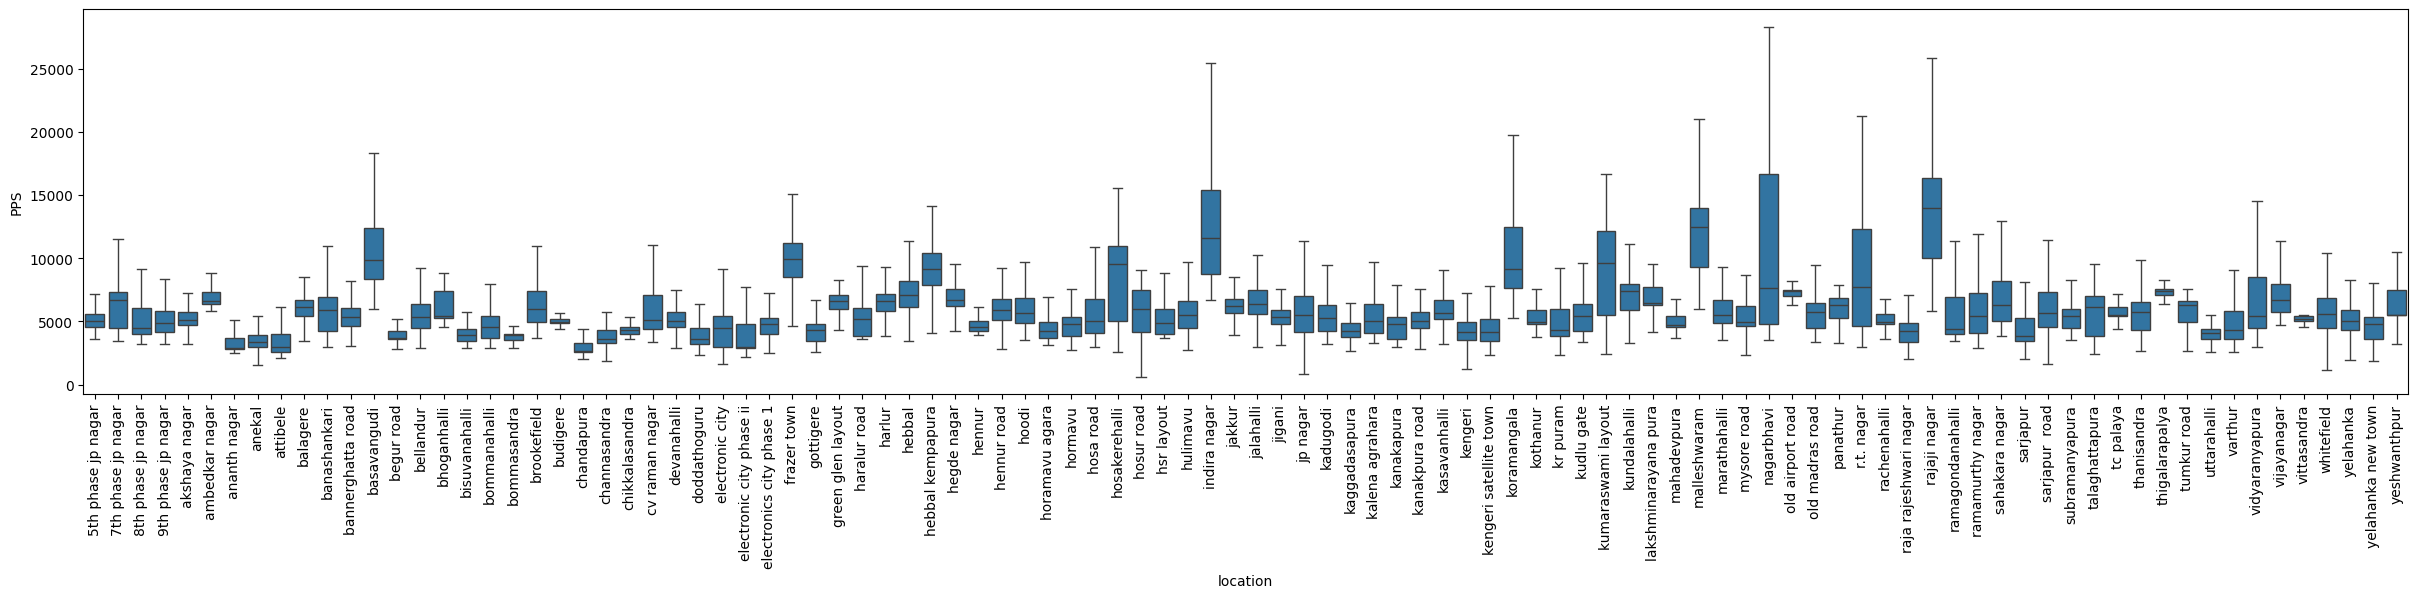

In [ ]:
import seaborn as sns

plt.figure(figsize = (30,5))
sns.boxplot(x = df7['location']  , y = df7['PPS'])

plt.xticks(rotation = 90)
plt.show()

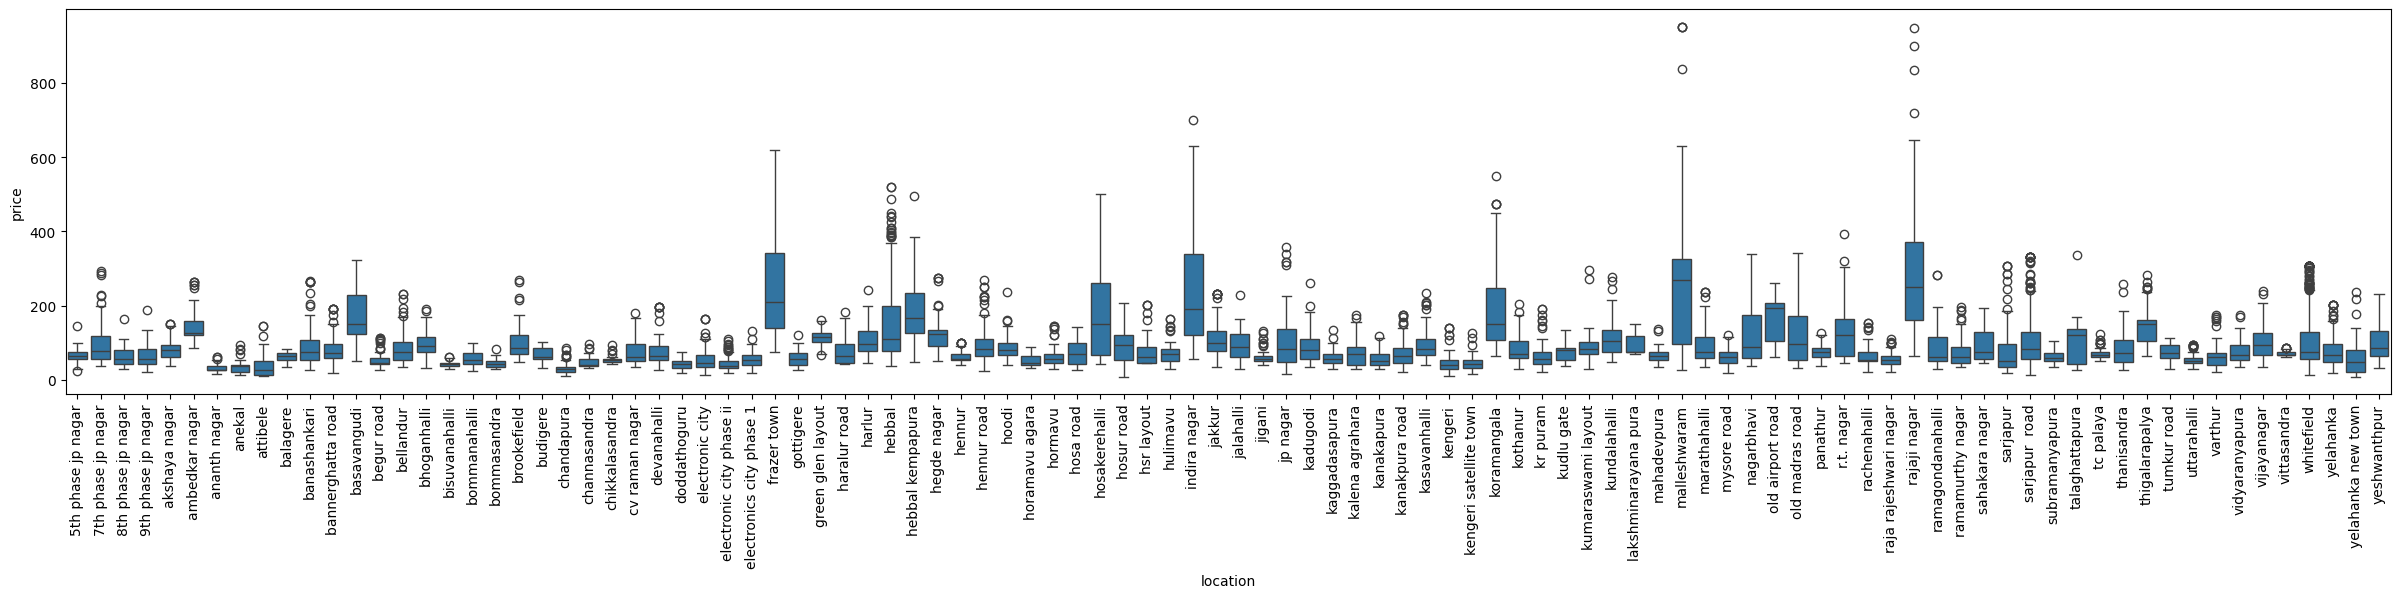

In [ ]:
import seaborn as sns

plt.figure(figsize = (30,5))
sns.boxplot(x = df7['location']  , y = df7['price'])

plt.xticks(rotation = 90)
plt.show()

In [ ]:
df6.describe()

,size,total_sqft,bath,balcony,price,PPS
count,7847.000000,7847.000000,7847.000000,7847.000000,7847.000000,7.847000e+03
mean,2.603160,1439.859091,2.526953,1.591946,98.577685,7.610647e+03
std,0.856387,567.586494,0.975748,0.779665,104.667404,1.354973e+05
min,1.000000,117.500000,1.000000,0.000000,8.000000,3.714286e+02
25%,2.000000,1109.000000,2.000000,1.000000,48.000000,4.200000e+03
50%,3.000000,1286.000000,2.000000,2.000000,69.000000,5.300078e+03
75%,3.000000,1655.500000,3.000000,2.000000,109.000000,6.764516e+03
max,6.000000,4965.625000,8.000000,3.000000,1800.000000,1.200000e+07


In [ ]:
df7.describe()

,size,total_sqft,bath,balcony,price,PPS
count,7847.000000,7847.000000,7847.000000,7847.000000,7847.000000,7847.000000
mean,2.603160,1439.859091,2.526953,1.591946,89.447427,5822.165392
std,0.856387,567.586494,0.975748,0.779665,72.883109,2564.638294
min,1.000000,117.500000,1.000000,0.000000,8.000000,625.185185
25%,2.000000,1109.000000,2.000000,1.000000,48.000000,4203.091183
50%,3.000000,1286.000000,2.000000,2.000000,68.000000,5294.117647
75%,3.000000,1655.500000,3.000000,2.000000,104.000000,6717.948718
max,6.000000,4965.625000,8.000000,3.000000,952.362867,28333.333333


In [ ]:
df7.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,PPS
367,super built-up area,Ready To Move,5th phase jp nagar,2.0,1075.0,2.0,2.0,60.0,5581.395349
493,Others,Ready To Move,5th phase jp nagar,2.0,1150.0,3.0,3.0,52.5,4565.217391
760,super built-up area,UC,5th phase jp nagar,2.0,1070.0,2.0,2.0,39.0,3644.859813
1012,Others,Ready To Move,5th phase jp nagar,2.0,1256.0,2.0,1.0,62.8,5000.000000
1493,super built-up area,Ready To Move,5th phase jp nagar,2.0,1207.0,2.0,2.0,63.0,5219.552610


In [ ]:
print(df7['area_type'].unique())
print(df7['availability'].unique())

['super built-up area' 'Others']
['Ready To Move' 'UC']


In [ ]:
df7['area_type'] = df7['area_type'].map({'super built-up area':0,  'Others':1})
df7['availability'] = df7['availability'].map({'Ready To Move':0,  'UC':1})

In [ ]:
df7.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,PPS
367,0,0,5th phase jp nagar,2.0,1075.0,2.0,2.0,60.0,5581.395349
493,1,0,5th phase jp nagar,2.0,1150.0,3.0,3.0,52.5,4565.217391
760,0,1,5th phase jp nagar,2.0,1070.0,2.0,2.0,39.0,3644.859813
1012,1,0,5th phase jp nagar,2.0,1256.0,2.0,1.0,62.8,5000.000000
1493,0,0,5th phase jp nagar,2.0,1207.0,2.0,2.0,63.0,5219.552610


In [ ]:
df8 = pd.get_dummies(df7,dtype=int)
df8.head()

,area_type,availability,size,total_sqft,bath,balcony,price,PPS,location_5th phase jp nagar,location_7th phase jp nagar,...,location_tumkur road,location_uttarahalli,location_varthur,location_vidyaranyapura,location_vijayanagar,location_vittasandra,location_whitefield,location_yelahanka,location_yelahanka new town,location_yeshwanthpur
367,0,0,2.0,1075.0,2.0,2.0,60.0,5581.395349,1,0,...,0,0,0,0,0,0,0,0,0,0
493,1,0,2.0,1150.0,3.0,3.0,52.5,4565.217391,1,0,...,0,0,0,0,0,0,0,0,0,0
760,0,1,2.0,1070.0,2.0,2.0,39.0,3644.859813,1,0,...,0,0,0,0,0,0,0,0,0,0
1012,1,0,2.0,1256.0,2.0,1.0,62.8,5000.000000,1,0,...,0,0,0,0,0,0,0,0,0,0
1493,0,0,2.0,1207.0,2.0,2.0,63.0,5219.552610,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df8.drop(columns=['price', 'PPS'])
y = df8['price']

In [ ]:
X.head()

,area_type,availability,size,total_sqft,bath,balcony,location_5th phase jp nagar,location_7th phase jp nagar,location_8th phase jp nagar,location_9th phase jp nagar,...,location_tumkur road,location_uttarahalli,location_varthur,location_vidyaranyapura,location_vijayanagar,location_vittasandra,location_whitefield,location_yelahanka,location_yelahanka new town,location_yeshwanthpur
367,0,0,2.0,1075.0,2.0,2.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493,1,0,2.0,1150.0,3.0,3.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
760,0,1,2.0,1070.0,2.0,2.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1012,1,0,2.0,1256.0,2.0,1.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1493,0,0,2.0,1207.0,2.0,2.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: ylabel='Frequency'>

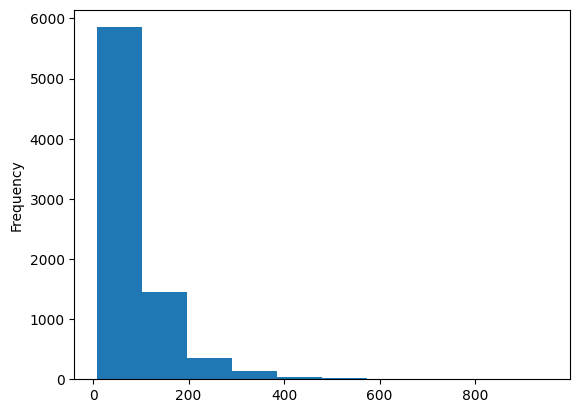

In [ ]:
y.plot.hist()

<Axes: ylabel='Frequency'>

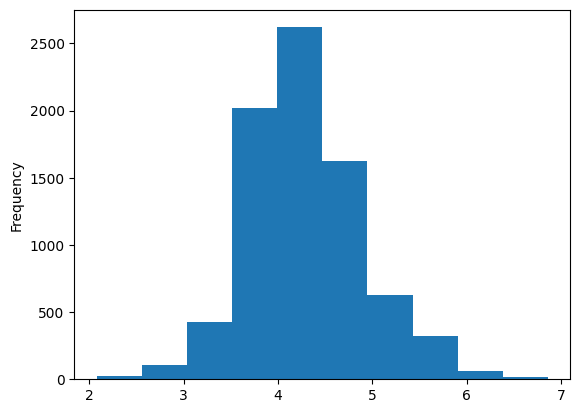

In [ ]:
np.log(y).plot.hist()

In [ ]:
Yt = np.log(y)

In [ ]:
X.shape

(7847, 106)

In [ ]:
X.head(2)

,area_type,availability,size,total_sqft,bath,balcony,location_5th phase jp nagar,location_7th phase jp nagar,location_8th phase jp nagar,location_9th phase jp nagar,...,location_tumkur road,location_uttarahalli,location_varthur,location_vidyaranyapura,location_vijayanagar,location_vittasandra,location_whitefield,location_yelahanka,location_yelahanka new town,location_yeshwanthpur
367,0,0,2.0,1075.0,2.0,2.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493,1,0,2.0,1150.0,3.0,3.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X)
Xscaled = scaler.transform(X)

In [ ]:
Xscaled

array([[0. , 0. , 0.2, ..., 0. , 0. , 0. ],
       [1. , 0. , 0.2, ..., 0. , 0. , 0. ],
       [0. , 1. , 0.2, ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0.4, ..., 0. , 0. , 1. ],
       [0. , 0. , 0.4, ..., 0. , 0. , 1. ],
       [0. , 0. , 0.4, ..., 0. , 0. , 1. ]])

In [ ]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(Xscaled,Yt)

In [ ]:
from sklearn.linear_model import LinearRegression
modelA = LinearRegression()
modelA.fit(xtrain,ytrain)

LinearRegression()

In [ ]:
ytrainPred = modelA.predict(xtrain)
ytestPred = modelA.predict(xtest)

In [ ]:
print("Mean absolute error(Train)-" , abs(ytrain - ytrainPred).mean())
print("Mean absolute error(Test)-" , abs(ytest - ytestPred).mean())

Mean absolute error(Train)- 0.20582863293199477
Mean absolute error(Test)- 0.204621583754627


In [ ]:
from sklearn.metrics import r2_score

print("r2_score_train" , r2_score(ytrain,ytrainPred))
print("r2_score_test" , r2_score(ytest,ytestPred))

r2_score_train 0.8134603938080839
r2_score_test 0.8089349469746641


In [ ]:
feature_coef = pd.DataFrame(modelA.coef_)
feature_coef.index = X.columns
feature_coef

,0
area_type,0.047456
availability,0.004876
size,0.483752
total_sqft,2.953750
bath,0.314758
...,...
location_vittasandra,0.072746
location_whitefield,-0.000308
location_yelahanka,-0.073583
location_yelahanka new town,-0.313791


<Axes: >

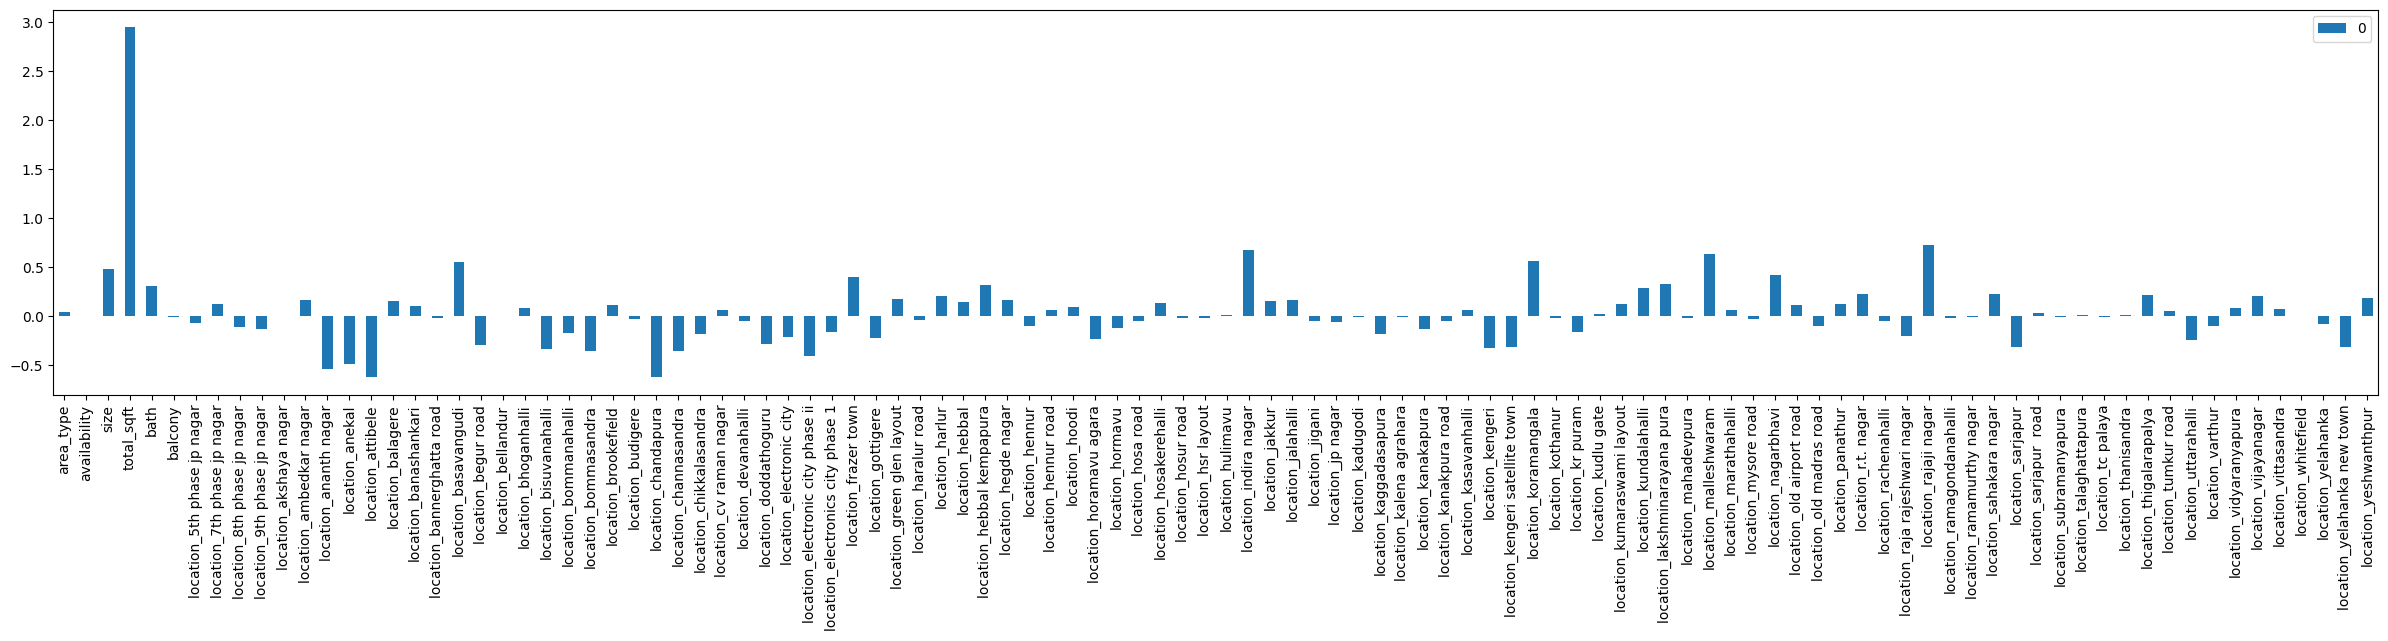

In [ ]:
feature_coef.plot.bar(figsize = (30,5))

**Save the artifacts for model deployment**

In [ ]:
import joblib

In [ ]:
joblib.dump(modelA , "real_estate.pkl")

['real_estate.pkl']

In [ ]:
joblib.dump(scaler, 'feature_scaling.pkl')

['feature_scaling.pkl']

In [ ]:
import json
training_data_columns = {"data_columns" : X.columns.to_list()}
json_data = json.dumps(training_data_columns)

my_json_file = open("training_data_columns.json" , "w")
my_json_file.write(json_data)
my_json_file.close()

**Prediction**

In [ ]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
area_type = "Super built-up Area"
availability = "Ready To Move"
location = "5th phase jp nagar"
size = 2
total_sqft = 1200
bath = 2
balcony = 2

In [ ]:
#Column names of training data
X.columns

Index(['area_type', 'availability', 'size', 'total_sqft', 'bath', 'balcony',
       'location_5th phase jp nagar', 'location_7th phase jp nagar',
       'location_8th phase jp nagar', 'location_9th phase jp nagar',
       ...
       'location_tumkur road', 'location_uttarahalli', 'location_varthur',
       'location_vidyaranyapura', 'location_vijayanagar',
       'location_vittasandra', 'location_whitefield', 'location_yelahanka',
       'location_yelahanka new town', 'location_yeshwanthpur'],
      dtype='object', length=106)

In [ ]:
input = np.zeros(len(X.columns))
input

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [ ]:
area_type_function = lambda area_type : 0 if area_type.lower().strip() == 'super built-up area' else 1
area_type_function(area_type)

0

In [ ]:
availability_function = lambda availability : 0 if availability == 'Ready To Move' else 1
availability_function(availability)

0

In [ ]:
area_type = "Super built-up Area"
availability = "Ready To Move"
location = "5th phase jp nagar"
size = 2
total_sqft = 1200
bath = 2
balcony = 2

In [ ]:
input[0] = area_type_function(area_type)
input[1] = availability_function(availability)
input[2] = size
input[3] = total_sqft
input[4] = bath
input[5] = balcony

In [ ]:
X.columns.to_list().index("location_" + location)

6

In [ ]:
input[6] = 1

In [ ]:
print(input)

[0.0e+00 0.0e+00 2.0e+00 1.2e+03 2.0e+00 2.0e+00 1.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]


In [ ]:
import joblib

_model = joblib.load('/content/real_estate.pkl')
_scaling = joblib.load('/content/feature_scaling.pkl')

In [ ]:
print(_model.predict(_scaling.transform([input])))

[3.988561]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
print(np.exp(_model.predict(_scaling.transform([input]))))

[53.97716032]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
